In [28]:
from IPython.display import HTML
HTML("<style>.container{width:100%!important;margin:auto}div.cell,div.input_area{padding:2px;margin:0}div.output_wrapper{padding:0;margin:0}</style>")

# Machine Learning Lecture 
## Topic: Decision Trees, Random Forests, and K-Nearest Neighbors (K-NN)

**Prerequisites you already have:** Python, Linear Algebra, Linear Regression (Day 1), Logistic Regression (Day 2)

---
### Today is different from Day 1 and Day 2!

On Day 1 and 2, our models were built from a **mathematical formula** ($wx+b$, then squashed by a sigmoid) and learned using **gradient descent**.

Today's three algorithms work completely differently:
- **Decision Trees** learn a series of "if-then" **questions**, like a flowchart
- **Random Forests** combine MANY decision trees together (a "team" of trees)
- **K-Nearest Neighbors (K-NN)** doesn't really "learn" a formula at all — it just remembers all the data and looks at "who's nearby"

### Learning Objectives
By the end of this notebook, you will be able to:
1. Explain how a Decision Tree makes predictions using yes/no questions
2. Understand **Gini Impurity** and **Entropy** — the math used to decide which question to ask first
3. Understand **overfitting** in trees and how **max depth** / pruning helps
4. Explain what a Random Forest is and why "many weak trees" beat "one big tree" (the wisdom of crowds)
5. Understand **Bagging** (Bootstrap Aggregating) and **feature randomness**
6. Explain how K-NN classifies a new point by looking at its nearest neighbors
7. Understand distance metrics (Euclidean distance) and how to choose K
8. Implement and evaluate all three models using scikit-learn, and compare them side-by-side


# PART 1: Decision Trees

## The Big Idea

A Decision Tree makes predictions by asking a series of **yes/no questions**, just like the game "20 Questions" or a flowchart you might draw to make a decision in real life.

### A simple example you already do in your head:

> "Should I bring an umbrella today?"
> - Is it cloudy? → **Yes** → Is the humidity high? → **Yes** →  Bring umbrella
> - Is it cloudy? → **No** →  Don't bring umbrella

This is exactly what a decision tree does — except the computer figures out **which questions to ask, and in what order**, directly from the data, instead of you writing the rules by hand.

### Vocabulary

- **Root node**: the very first question (top of the tree)
- **Internal node**: any question node in the middle of the tree
- **Branch**: the "Yes"/"No" (or True/False) path leading out of a question
- **Leaf node**: the final answer / prediction at the bottom of a branch — no more questions after this
- **Depth**: how many questions deep the tree goes before reaching a leaf

### Our running example today
Let's predict whether a student **passes (1)** or **fails (0)** an exam, using two features this time:
- `hours_studied`
- `hours_slept`

A decision tree might learn something like:
> "Is hours_studied > 3?" → Yes → "Is hours_slept > 6?" → Yes → **Predict: Pass**


   hours_studied  hours_slept  passed
0       0.763083     3.139142       0
1       7.799188     6.148319       1
2       4.384092     7.180175       0
3       7.234652     5.562321       0
4       9.779895     3.807423       1

Class balance:
passed
0    102
1     48
Name: count, dtype: int64


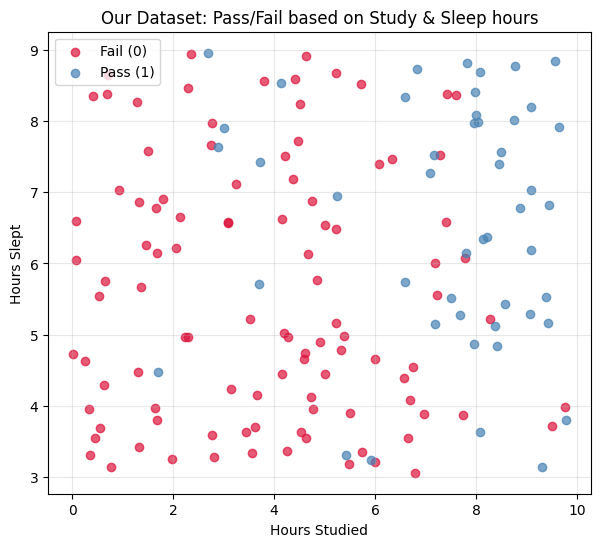

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Simulate a dataset with two features: hours studied and hours slept
np.random.seed(7)
n = 150
hours_studied = np.random.uniform(0, 10, n)
hours_slept = np.random.uniform(3, 9, n)

# A rule-ish but noisy true relationship
score = 0.6 * hours_studied + 0.4 * hours_slept + np.random.normal(0, 1.5, n)
passed = (score > 6.5).astype(int)

df = pd.DataFrame({
    'hours_studied': hours_studied,
    'hours_slept': hours_slept,
    'passed': passed
})
print(df.head())
print(f"\nClass balance:\n{df['passed'].value_counts()}")

# Visualize the two classes in feature space
plt.figure(figsize=(7, 6))
plt.scatter(df[df.passed==0]['hours_studied'], df[df.passed==0]['hours_slept'],
            color='crimson', label='Fail (0)', alpha=0.7)
plt.scatter(df[df.passed==1]['hours_studied'], df[df.passed==1]['hours_slept'],
            color='steelblue', label='Pass (1)', alpha=0.7)
plt.xlabel("Hours Studied")
plt.ylabel("Hours Slept")
plt.title("Our Dataset: Pass/Fail based on Study & Sleep hours")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## How does the tree decide WHICH question to ask first?

This is the key idea. The tree tries many possible questions like:
- "Is hours_studied > 2?"
- "Is hours_studied > 5?"
- "Is hours_slept > 6?"

...and picks the question that best **splits** the data into groups that are as "pure" as possible — meaning each resulting group is mostly one class (mostly Pass, or mostly Fail).

The goal of every question is to maximize **Purity**:
*   **High Impurity (Chaos):** If a group of data is a messy 50/50 mix of "Will Play" and "Will Sleep", the AI is confused.
*   **High Purity (Order):** The AI wants to ask a question that splits the data so one side is 100% "Will Play" and the other is 100% "Will Sleep".

* To measure this chaos and find the cleanest split, the AI uses a formula called Gini Impurity or Shannon Entropy 

### Measuring "Purity" — Gini Impurity

The most common way to measure how "mixed up" a group is, is **Gini Impurity**:

$$
Gini = 1 - \sum_{i=1}^{C} p_i^2
$$

Where:
- $C$ is the number of classes (here, 2: Pass and Fail)
- $p_i$ is the proportion (fraction) of class $i$ in that group

### Let's understand this with concrete numbers:

**Case A: A perfectly pure group** — all 10 students in a group Passed (10 Pass, 0 Fail)
- $p_{pass} = 1.0$, $p_{fail} = 0.0$
- $Gini = 1 - (1.0^2 + 0.0^2) = 1 - 1 = 0$
- **Gini = 0 means perfectly pure** (no mixing at all) — the best possible outcome for a leaf

**Case B: A perfectly mixed group** — 5 Pass, 5 Fail (50/50 split)
- $p_{pass} = 0.5$, $p_{fail} = 0.5$
- $Gini = 1 - (0.5^2 + 0.5^2) = 1 - (0.25+0.25) = 1 - 0.5 = 0.5$
- **Gini = 0.5 is the maximum impurity for 2 classes** (totally mixed, 50/50 — a coin flip)

So: **lower Gini = purer group = better split.**

### An alternative: Entropy (from Information Theory)

$$
Entropy = -\sum_{i=1}^{C} p_i \log_2(p_i)
$$

Entropy works very similarly to Gini (0 = pure, higher = more mixed), just measured on a different mathematical scale (it comes from information theory — literally measuring "how many yes/no questions, on average, would you need to identify the class"). scikit-learn lets you choose either `gini` or `entropy`; in practice, they usually give very similar trees.

### Information Gain — picking the BEST question

For every candidate question (e.g., "hours_studied > 5?"), the tree calculates:

$$
\text{Information Gain} = Gini_{parent} - \Big(\text{weighted average of } Gini_{children}\Big)
$$

In plain English: **"How much did asking this question reduce the impurity, compared to before we asked it?"**

The tree tries every possible question (every feature, every possible threshold value) and picks the one with the **highest information gain** — the question that does the best job separating Pass from Fail. Then it repeats this process again on each resulting group, recursively, building the tree question by question.


In [30]:
# Let's calculate Gini impurity by hand for a few example groups, to build intuition

def gini_impurity(labels):
    labels = np.array(labels)
    if len(labels) == 0:
        return 0
    p_pass = np.mean(labels == 1)
    p_fail = np.mean(labels == 0)
    return 1 - (p_pass**2 + p_fail**2)

# Example groups
group_pure_pass = [1, 1, 1, 1, 1]          # all passed
group_pure_fail = [0, 0, 0, 0, 0]          # all failed
group_mixed_50_50 = [1, 0, 1, 0, 1, 0]     # perfectly mixed
group_mostly_pass = [1, 1, 1, 1, 0]        # mostly passed, one fail

print(f"Gini(all Pass):        {gini_impurity(group_pure_pass):.3f}  <- perfectly pure")
print(f"Gini(all Fail):        {gini_impurity(group_pure_fail):.3f}  <- perfectly pure")
print(f"Gini(50/50 mixed):     {gini_impurity(group_mixed_50_50):.3f}  <- maximum impurity")
print(f"Gini(mostly Pass):     {gini_impurity(group_mostly_pass):.3f}  <- somewhat impure")


Gini(all Pass):        0.000  <- perfectly pure
Gini(all Fail):        0.000  <- perfectly pure
Gini(50/50 mixed):     0.500  <- maximum impurity
Gini(mostly Pass):     0.320  <- somewhat impure


In [31]:
# Now let's manually test ONE candidate split, to see how "Information Gain" is calculated

# Candidate question: "Is hours_studied > 5?"
threshold = 5
left_group = df[df['hours_studied'] <= 5]['passed']   # students who studied 5 hours or less
right_group = df[df['hours_studied'] > 5]['passed']   # students who studied more than 5 hours

gini_parent = gini_impurity(df['passed'])
gini_left = gini_impurity(left_group)
gini_right = gini_impurity(right_group)

# Weighted average of children (weighted by how many students fall in each group)
n_total = len(df)
weighted_gini_children = (len(left_group)/n_total) * gini_left + (len(right_group)/n_total) * gini_right

information_gain = gini_parent - weighted_gini_children

print(f"Gini BEFORE split (parent, all students):      {gini_parent:.3f}")
print(f"Gini of 'hours_studied <= 5' group ({len(left_group)} students):  {gini_left:.3f}")
print(f"Gini of 'hours_studied > 5' group ({len(right_group)} students):  {gini_right:.3f}")
print(f"Weighted average Gini AFTER split:              {weighted_gini_children:.3f}")
print(f"\nInformation Gain from this split: {information_gain:.3f}")
print("\n(A real decision tree tries MANY thresholds like this, for every feature,")
print(" and picks whichever split gives the HIGHEST information gain.)")


Gini BEFORE split (parent, all students):      0.435
Gini of 'hours_studied <= 5' group (78 students):  0.163
Gini of 'hours_studied > 5' group (72 students):  0.490
Weighted average Gini AFTER split:              0.320

Information Gain from this split: 0.115

(A real decision tree tries MANY thresholds like this, for every feature,
 and picks whichever split gives the HIGHEST information gain.)


## The Danger of Decision Trees: Overfitting

If we let a tree keep asking questions with **no limit**, it can keep splitting until every single leaf contains just ONE data point, perfectly memorizing the training data. This sounds great, but it's actually a big problem, called **overfitting**.

### Why is a super-deep tree bad?

Imagine a tree so specific it learns rules like: *"If hours_studied is EXACTLY 4.237 AND hours_slept is EXACTLY 6.891, then Pass."* This rule only works because of one specific data point's noise/randomness — it won't generalize to new students at all. The tree has **memorized the training data** instead of **learning the real underlying pattern**.

### How do we prevent this?

We control the tree's complexity using hyperparameters (settings we choose, similar to the learning rate on Day 1):

| Hyperparameter | What it controls |
|---|---|
| `max_depth` | Maximum number of questions deep the tree can go |
| `min_samples_split` | Minimum number of data points required before a node is allowed to split further |
| `min_samples_leaf` | Minimum number of data points required to be in each final leaf |

This process of limiting tree growth is called **pruning**. We'll see this in action below by comparing a shallow tree vs. a very deep tree.


In [32]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

X = df[['hours_studied', 'hours_slept']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Train TWO trees: one shallow (max_depth=2), one very deep (max_depth=None -> unlimited)
shallow_tree = DecisionTreeClassifier(max_depth=2, random_state=42)
shallow_tree.fit(X_train, y_train)

deep_tree = DecisionTreeClassifier(max_depth=None, random_state=42)  # no limit!
deep_tree.fit(X_train, y_train)

# Compare training accuracy vs test accuracy for both
for name, tree in [("Shallow tree (max_depth=2)", shallow_tree), ("Deep tree (max_depth=None)", deep_tree)]:
    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc = accuracy_score(y_test, tree.predict(X_test))
    print(f"{name}:")
    print(f"   Training accuracy: {train_acc:.3f}")
    print(f"   Test accuracy:     {test_acc:.3f}")
    print(f"   Gap (train - test): {train_acc - test_acc:.3f}  <- a BIG gap means overfitting!\n")


Shallow tree (max_depth=2):
   Training accuracy: 0.875
   Test accuracy:     0.816
   Gap (train - test): 0.059  <- a BIG gap means overfitting!

Deep tree (max_depth=None):
   Training accuracy: 1.000
   Test accuracy:     0.711
   Gap (train - test): 0.289  <- a BIG gap means overfitting!



### What to notice in the output above

The **deep tree** usually gets very high (maybe even 100%) accuracy on the **training** data — it has basically memorized it. But look at the **test** accuracy — the deep tree often does no better (or even worse) than the shallow tree on data it hasn't seen before.

**A large gap between training accuracy and test accuracy is the classic warning sign of overfitting.** This is exactly why we always evaluate on a held-out test set, just like we learned on Day 1!


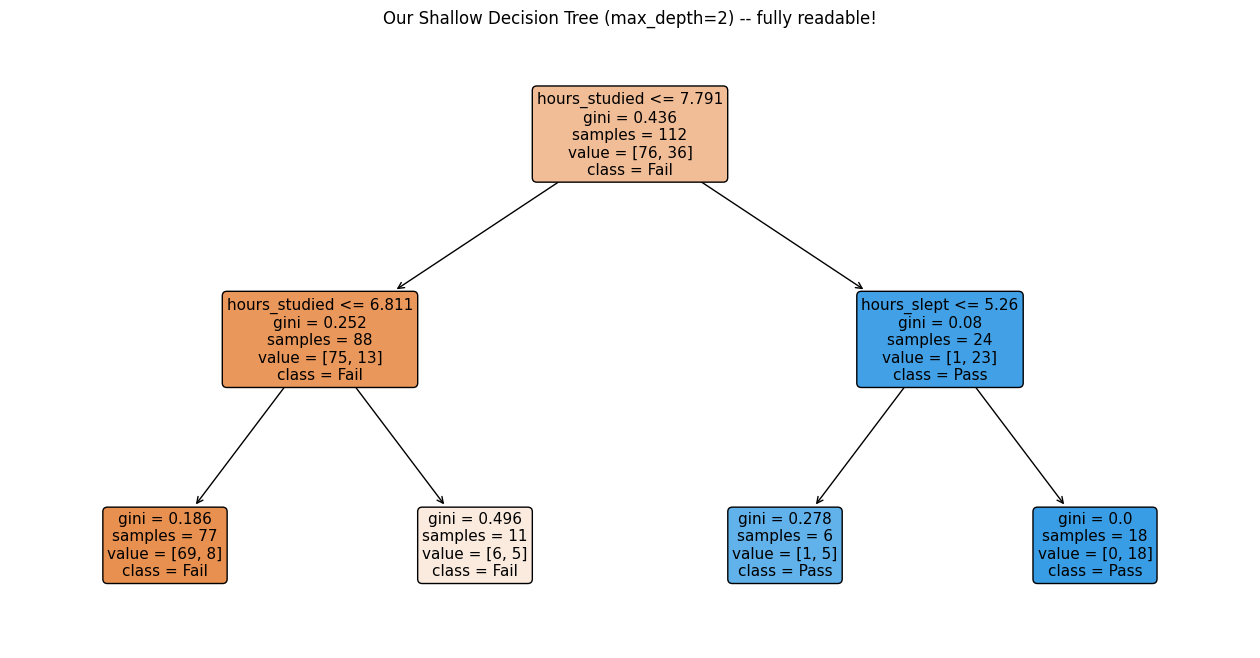

Reading a node in the tree above:
- Top line: the yes/no QUESTION being asked at that node
- 'gini': the Gini impurity of that group (0 = pure)
- 'samples': how many training students fall into that node
- 'value': [count of Fail, count of Pass] in that node
- 'class': the majority class prediction for that node


In [33]:
# Let's actually SEE the shallow tree's decision rules -- this is one of the best things about trees:
# they are highly INTERPRETABLE (you can literally read the "if-then" logic).

plt.figure(figsize=(16, 8))
plot_tree(shallow_tree, feature_names=['hours_studied', 'hours_slept'],
          class_names=['Fail', 'Pass'], filled=True, rounded=True, fontsize=11)
plt.title("Our Shallow Decision Tree (max_depth=2) -- fully readable!")
plt.show()

print("Reading a node in the tree above:")
print("- Top line: the yes/no QUESTION being asked at that node")
print("- 'gini': the Gini impurity of that group (0 = pure)")
print("- 'samples': how many training students fall into that node")
print("- 'value': [count of Fail, count of Pass] in that node")
print("- 'class': the majority class prediction for that node")


/share/pkg.8/python3/3.10.12/install/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


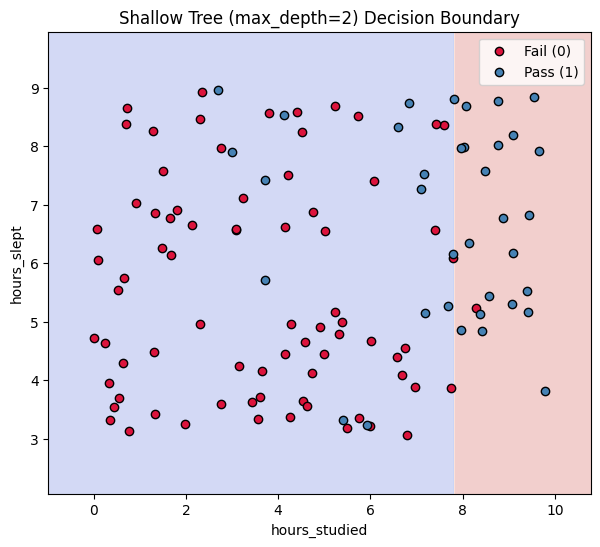

/share/pkg.8/python3/3.10.12/install/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


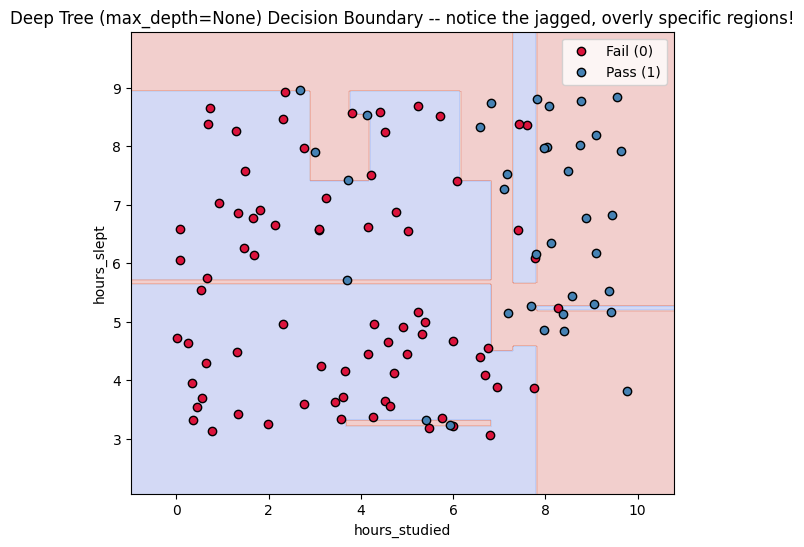

Notice: the shallow tree makes a few clean, simple splits (straight rectangular regions).
The deep tree carves out tiny, jagged little regions to fit individual noisy points --
a visual picture of overfitting.


In [34]:
# Visualize the DECISION BOUNDARY the shallow tree learned, in 2D feature space
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X.iloc[:,0].min()-1, X.iloc[:,0].max()+1
    y_min, y_max = X.iloc[:,1].min()-1, X.iloc[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    plt.scatter(X[y==0].iloc[:,0], X[y==0].iloc[:,1], color='crimson', label='Fail (0)', edgecolor='k')
    plt.scatter(X[y==1].iloc[:,0], X[y==1].iloc[:,1], color='steelblue', label='Pass (1)', edgecolor='k')
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.title(title)
    plt.legend()
    plt.show()

plot_decision_boundary(shallow_tree, X_train, y_train, "Shallow Tree (max_depth=2) Decision Boundary")
plot_decision_boundary(deep_tree, X_train, y_train, "Deep Tree (max_depth=None) Decision Boundary -- notice the jagged, overly specific regions!")

print("Notice: the shallow tree makes a few clean, simple splits (straight rectangular regions).")
print("The deep tree carves out tiny, jagged little regions to fit individual noisy points --")
print("a visual picture of overfitting.")


---
# PART 2: Random Forests

## The Big Idea: "Wisdom of the Crowd"

A single decision tree, especially a deep one, tends to overfit and can be unstable (a small change in the training data might produce a very different tree). 

**Random Forest** solves this with a simple but powerful idea: **instead of building ONE tree, build MANY trees (e.g., 100 or 500), each slightly different, and let them VOTE on the final answer.**

This is inspired by the **"wisdom of crowds"**: if you ask one random person to guess the number of jellybeans in a jar, they might be way off. But if you ask 500 people and average their guesses, the average is often surprisingly accurate — individual errors tend to cancel out, while the shared true signal reinforces itself.

### How do we make each tree "different"? Two sources of randomness:

### 1. Bagging (Bootstrap Aggregating)

Each tree is trained on a **random sample of the training data, drawn WITH replacement** (called a "bootstrap sample"). This means:
- Some data points might appear multiple times in one tree's training sample
- Some data points might not appear at all in that tree's sample
- Each tree therefore sees a slightly different "view" of the data, and so learns slightly different rules

### 2. Random Feature Selection

When each tree is deciding on the best question to split on, it's only allowed to consider a **random subset of features** (not all of them) at each split. This forces trees to be more different from each other — otherwise, if one feature is very strong, EVERY tree would just use that same feature first and they'd all end up nearly identical.

### Making the Final Prediction

- **For classification:** each of the many trees votes for a class (Pass/Fail), and the **majority vote** wins
- **For regression:** each tree predicts a number, and the **average** of all trees' predictions is the final output

### Why does this reduce overfitting?

A single deep tree overfits to the specific noise in the training data. But since each tree in the forest sees a different random sample of data and features, each tree "overfits" to *different* noise. When we average/vote across all of them, these individual errors tend to **cancel out**, while the real underlying pattern (which all trees can detect) gets reinforced. This is the same "wisdom of crowds" effect.


In [35]:
from sklearn.ensemble import RandomForestClassifier

# Train a Random Forest with 200 trees
forest = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
forest.fit(X_train, y_train)

train_acc = accuracy_score(y_train, forest.predict(X_train))
test_acc = accuracy_score(y_test, forest.predict(X_test))

print(f"Random Forest (200 trees, max_depth=4):")
print(f"   Training accuracy: {train_acc:.3f}")
print(f"   Test accuracy:     {test_acc:.3f}")
print(f"   Gap (train - test): {train_acc - test_acc:.3f}")

print(f"\nCompare to our single Deep Tree from before:")
print(f"   Deep tree test accuracy was: {accuracy_score(y_test, deep_tree.predict(X_test)):.3f}")
print("\nThe forest typically has a SMALLER train/test gap than a single deep tree --")
print("evidence that combining many trees reduces overfitting.")


Random Forest (200 trees, max_depth=4):
   Training accuracy: 0.929
   Test accuracy:     0.789
   Gap (train - test): 0.139

Compare to our single Deep Tree from before:
   Deep tree test accuracy was: 0.711

The forest typically has a SMALLER train/test gap than a single deep tree --
evidence that combining many trees reduces overfitting.


/share/pkg.8/python3/3.10.12/install/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


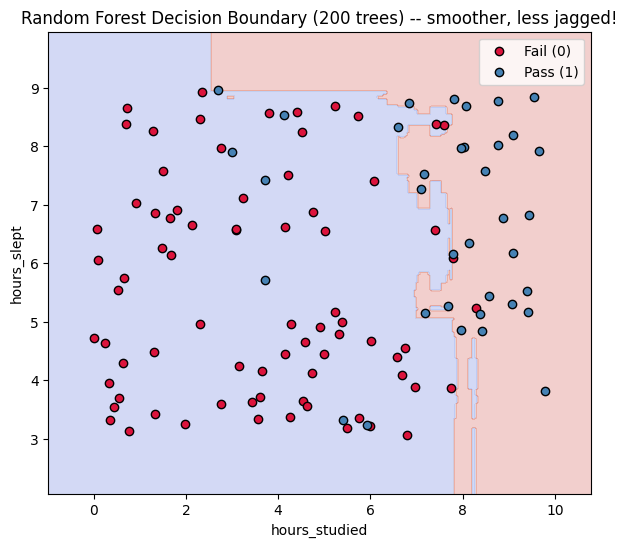

In [36]:
# Visualize the Random Forest's decision boundary -- notice it's much smoother than a single deep tree
plot_decision_boundary(forest, X_train, y_train, "Random Forest Decision Boundary (200 trees) -- smoother, less jagged!")


## Bonus: Feature Importance

A really useful side-benefit of Random Forests: they can tell us **which features mattered most** for making predictions, by measuring how much each feature reduced impurity (Gini) on average, across all trees in the forest.


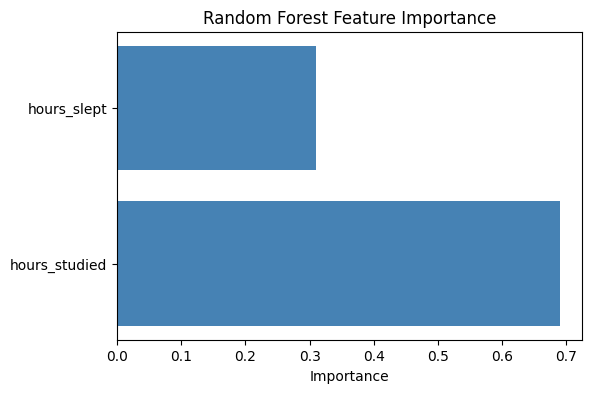

hours_studied: 0.690
hours_slept: 0.310

Higher importance = this feature was more useful, on average, across all 200 trees,
for correctly separating Pass from Fail students.


In [37]:
importances = forest.feature_importances_
feature_names = X.columns

plt.figure(figsize=(6, 4))
plt.barh(feature_names, importances, color='steelblue')
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

for name, imp in zip(feature_names, importances):
    print(f"{name}: {imp:.3f}")
print("\nHigher importance = this feature was more useful, on average, across all 200 trees,")
print("for correctly separating Pass from Fail students.")


---
# PART 3: K-Nearest Neighbors (K-NN)

## The Big Idea: "You are the average of your neighbors"

K-NN is probably the SIMPLEST machine learning algorithm conceptually, because it doesn't really "train" a model with formulas or trees at all. Instead:

> **To classify a new data point, look at the K closest points to it in the training data, and let them vote on the class.**

This is often called a **"lazy learner"** — there's no real training phase. The model just **stores** the entire training dataset, and does all its "work" at prediction time by measuring distances.

### A simple real-life analogy

Imagine you move to a new neighborhood and want to guess if your neighbors are generally friendly. A reasonable strategy: look at the **5 closest houses** to yours, and see whether most of them are friendly or not. That's K-NN, with K=5!

## Step-by-step: How K-NN classifies a new point

1. Pick a value for **K** (e.g., K=3)
2. Calculate the **distance** from the new point to EVERY point in the training set
3. Find the **K closest** training points (the "K nearest neighbors")
4. Let those K neighbors **vote**: whichever class is most common among them becomes the prediction

## Measuring "Distance" — Euclidean Distance

The most common distance measure is **Euclidean distance** — literally the straight-line distance you'd measure with a ruler, extended to any number of dimensions/features. For two points with features $(x_1, y_1)$ and $(x_2, y_2)$:

$$
\text{distance} = \sqrt{(x_2-x_1)^2 + (y_2-y_1)^2}
$$

This is just the **Pythagorean theorem** you already know from geometry! For more than 2 features, it generalizes naturally:

$$
\text{distance} = \sqrt{\sum_{i=1}^{n}(x_{2,i} - x_{1,i})^2}
$$

We simply add up the squared differences across ALL features, then take the square root.

## Choosing K — a critical decision

- **K too small (e.g., K=1):** the prediction depends on just ONE nearest neighbor, which could easily be noisy or an outlier. This tends to **overfit** (very jagged, sensitive decision boundary).
- **K too large (e.g., K=100, close to the whole dataset):** the prediction gets "smoothed out" so much it basically just predicts the overall majority class everywhere, ignoring local patterns. This tends to **underfit**.
- We usually try several values of K and pick the one that performs best on a validation/test set.

## An important practical detail: Feature Scaling

Since K-NN relies entirely on distance calculations, features with **larger numeric ranges will dominate the distance calculation**, even if they're not actually more important. For example, if `hours_studied` ranges 0-10 but `annual_family_income` ranges 0-100,000, the income feature would completely dominate the distance calculation just because its NUMBERS are bigger — not because it's more informative! 

**This is why we always scale/standardize features before using K-NN** (and several other distance-based algorithms), typically so every feature has mean 0 and standard deviation 1.


# PART 3: K-Nearest Neighbors (K-NN) Step-by-Step

Let's see how K-NN works in action. Imagine we want to predict whether a player will **Win** or **Lose** their next match based on two input features:
1. **Hours Practiced ($x_1$)** 
2. **Game Ping ($x_2$)** 

Our target output (ground truth) is **$y$** (Win or Lose).

We will use $K = 3$, meaning we will let the **3 closest neighbors** vote on the outcome.

### Our Training Data (Existing Players):
Each player has features $(x_1, x_2)$ and an output label $y$:
*   **Player A:** $(1, 2) \rightarrow y = \text{Lose}$
*   **Player B:** $(2, 4) \rightarrow y = \text{Lose}$
*   **Player C:** $(8, 3) \rightarrow y = \text{Win}$
*   **Player D:** $(9, 1) \rightarrow y = \text{Win}$

To classify a new player, we use the **Euclidean Distance** formula based on our two features:
$$\text{Distance} = \sqrt{(x_{1, new} - x_{1, train})^2 + (x_{2, new} - x_{2, train})^2}$$

---

## LOOP 1: Classifying New Player 1 at $(2, 2)$
*This player has $x_1 = 2$ (hours practiced) and $x_2 = 2$ (ping).*

| Training Player | Distance Calculation | Distance | Output ($y$) |
| :---: | :---: | :---: | :---: |
| **Player A** $(1, 2)$ | $\sqrt{(2-1)^2 + (2-2)^2} = \sqrt{1+0}$ | **$1.00$** | **Lose** |
| **Player B** $(2, 4)$ | $\sqrt{(2-2)^2 + (2-4)^2} = \sqrt{0+4}$ | **$2.00$** | **Lose** |
| **Player C** $(8, 3)$ | $\sqrt{(2-8)^2 + (2-3)^2} = \sqrt{36+1}$ | **$6.08$** | **Win** |
| **Player D** $(9, 1)$ | $\sqrt{(2-9)^2 + (2-1)^2} = \sqrt{49+1}$ | **$7.07$** | **Win** |

### Voting (K = 3):
The 3 closest neighbors are **Player A** (1.00), **Player B** (2.00), and **Player C** (6.08).
*   **Lose ($y$):** 2 votes (A, B)
*   **Win ($y$):** 1 vote (C)

**Predicted $y$ for Player 1:** $\rightarrow$ **Lose**

---

## LOOP 2: Classifying New Player 2 at $(8, 2)$
*This player has $x_1 = 8$ (hours practiced) and $x_2 = 2$ (ping).*

| Training Player | Distance Calculation | Distance | Output ($y$) |
| :---: | :---: | :---: | :---: |
| **Player A** $(1, 2)$ | $\sqrt{(8-1)^2 + (2-2)^2} = \sqrt{49+0}$ | **$7.00$** | **Lose** |
| **Player B** $(2, 4)$ | $\sqrt{(8-2)^2 + (2-4)^2} = \sqrt{36+4}$ | **$6.32$** | **Lose** |
| **Player C** $(8, 3)$ | $\sqrt{(8-8)^2 + (2-3)^2} = \sqrt{0+1}$ | **$1.00$** | **Win** |
| **Player D** $(9, 1)$ | $\sqrt{(8-9)^2 + (2-1)^2} = \sqrt{1+1}$ | **$1.41$** | **Win** |

### Voting (K = 3):
The 3 closest neighbors are **Player C** (1.00), **Player D** (1.41), and **Player B** (6.32).
*   **Win ($y$):** 2 votes (C, D)
*   **Lose ($y$):** 1 vote (B)

**Predicted $y$ for Player 2:** $\rightarrow$ **Win**

---

## LOOP 3: Classifying New Player 3 at $(3, 3)$
*This player has $x_1 = 3$ (hours practiced) and $x_2 = 3$ (ping).*

| Training Player | Distance Calculation | Distance | Output ($y$) |
| :---: | :---: | :---: | :---: |
| **Player A** $(1, 2)$ | $\sqrt{(3-1)^2 + (3-2)^2} = \sqrt{4+1}$ | **$2.24$** | **Lose** |
| **Player B** $(2, 4)$ | $\sqrt{(3-2)^2 + (3-4)^2} = \sqrt{1+1}$ | **$1.41$** | **Lose** |
| **Player C** $(8, 3)$ | $\sqrt{(3-8)^2 + (3-3)^2} = \sqrt{25+0}$ | **$5.00$** | **Win** |
| **Player D** $(9, 1)$ | $\sqrt{(3-9)^2 + (3-1)^2} = \sqrt{36+4}$ | **$6.32$** | **Win** |

### Voting (K = 3):
The 3 closest neighbors are **Player B** (1.41), **Player A** (2.24), and **Player C** (5.00).
*   **Lose ($y$):** 2 votes (B, A)
*   **Win ($y$):** 1 vote (C)

**Predicted $y$ for Player 3:** $\rightarrow$ **Lose**

In [38]:
# First, let's manually calculate the distance from one new student to a few training students,
# to build intuition before letting scikit-learn do it for many points automatically.

new_student = np.array([5, 7])  # hypothetical new student: 5 hours studied, 7 hours slept

sample_points = X_train.values[:5]
sample_labels = y_train.values[:5]

print(f"New student to classify: hours_studied={new_student[0]}, hours_slept={new_student[1]}\n")

for i, (point, label) in enumerate(zip(sample_points, sample_labels)):
    # Euclidean distance formula, calculated manually
    distance = np.sqrt(np.sum((point - new_student) ** 2))
    label_name = "Pass" if label == 1 else "Fail"
    print(f"Training student {i}: (studied={point[0]:.2f}, slept={point[1]:.2f}, actual={label_name}) "
          f"-> distance = {distance:.3f}")

print("\nK-NN would find the K training students with the SMALLEST distance to the new student,")
print("and have them vote on whether the new student will Pass or Fail.")


New student to classify: hours_studied=5, hours_slept=7

Training student 0: (studied=0.34, slept=3.96, actual=Fail) -> distance = 5.567
Training student 1: (studied=4.53, slept=3.64, actual=Fail) -> distance = 3.392
Training student 2: (studied=4.22, slept=7.51, actual=Fail) -> distance = 0.930
Training student 3: (studied=0.92, slept=7.03, actual=Fail) -> distance = 4.078
Training student 4: (studied=0.36, slept=3.32, actual=Fail) -> distance = 5.928

K-NN would find the K training students with the SMALLEST distance to the new student,
and have them vote on whether the new student will Pass or Fail.


In [39]:
# Feature scaling: crucial for K-NN! Let's see WHY using StandardScaler.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learn mean/std from TRAINING data only
X_test_scaled = scaler.transform(X_test)          # apply the SAME transformation to test data

print("Before scaling (first 3 training rows):")
print(X_train.values[:3])
print("\nAfter scaling (first 3 training rows) -- now both features are on a similar scale:")
print(X_train_scaled[:3].round(3))

print("\nNote: we call .fit_transform() on TRAINING data (learn the scaling parameters),")
print("but only .transform() on TEST data (reuse the SAME parameters -- we must never let")
print("the test set influence how we scale, or we'd be 'cheating' by peeking at test data).")


Before scaling (first 3 training rows):
[[0.33674205 3.96020077]
 [4.52842933 3.64126047]
 [4.22374044 7.51172137]]

After scaling (first 3 training rows) -- now both features are on a similar scale:
[[-1.569 -1.07 ]
 [-0.113 -1.243]
 [-0.219  0.852]]

Note: we call .fit_transform() on TRAINING data (learn the scaling parameters),
but only .transform() on TEST data (reuse the SAME parameters -- we must never let
the test set influence how we scale, or we'd be 'cheating' by peeking at test data).


In [40]:
from sklearn.neighbors import KNeighborsClassifier

# Train a K-NN classifier with K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

train_acc = accuracy_score(y_train, knn.predict(X_train_scaled))
test_acc = accuracy_score(y_test, knn.predict(X_test_scaled))

print(f"K-NN (K=5) with scaled features:")
print(f"   Training accuracy: {train_acc:.3f}")
print(f"   Test accuracy:     {test_acc:.3f}")


K-NN (K=5) with scaled features:
   Training accuracy: 0.875
   Test accuracy:     0.711


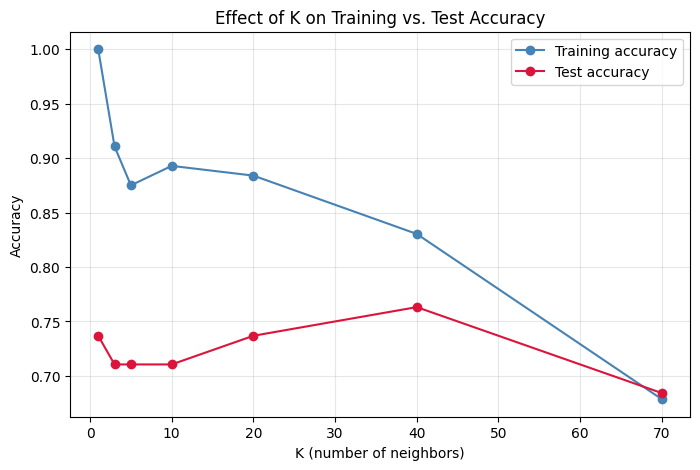

Small K (like 1): training accuracy is very high (almost memorizing), but test accuracy may suffer -- overfitting.
Large K: both accuracies tend to drop and flatten out -- underfitting (too smoothed out).
The best K is usually somewhere in the middle -- look for where TEST accuracy peaks.


In [41]:
# Let's see the effect of different K values -- demonstrating the underfit/overfit trade-off

k_values = [1, 3, 5, 10, 20, 40, 70]
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    train_accuracies.append(accuracy_score(y_train, knn_k.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test, knn_k.predict(X_test_scaled)))

plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracies, marker='o', color='steelblue', label='Training accuracy')
plt.plot(k_values, test_accuracies, marker='o', color='crimson', label='Test accuracy')
plt.xlabel("K (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("Effect of K on Training vs. Test Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Small K (like 1): training accuracy is very high (almost memorizing), but test accuracy may suffer -- overfitting.")
print("Large K: both accuracies tend to drop and flatten out -- underfitting (too smoothed out).")
print("The best K is usually somewhere in the middle -- look for where TEST accuracy peaks.")


/share/pkg.8/python3/3.10.12/install/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


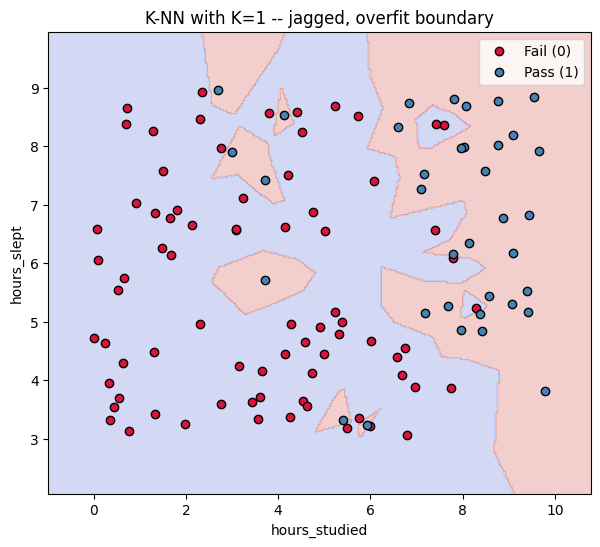

/share/pkg.8/python3/3.10.12/install/lib/python3.10/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


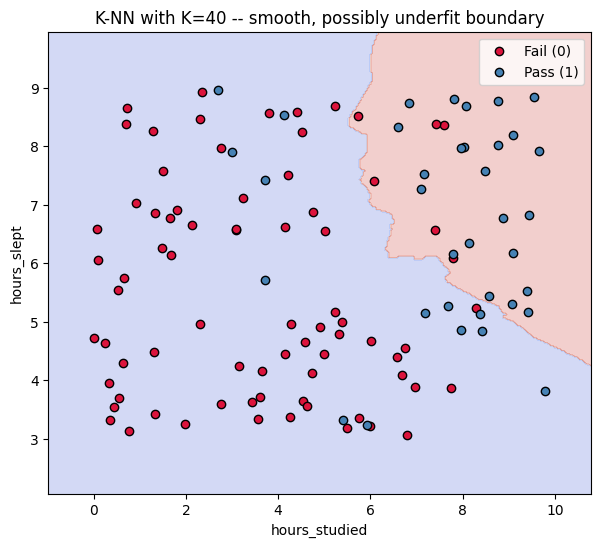

In [42]:
# Visualize K-NN's decision boundary for a small K vs a large K (need unscaled-consistent plotting helper)

def plot_decision_boundary_scaled(model, X_raw, y, scaler, title):
    x_min, x_max = X_raw.iloc[:,0].min()-1, X_raw.iloc[:,0].max()+1
    y_min, y_max = X_raw.iloc[:,1].min()-1, X_raw.iloc[:,1].max()+1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_points_scaled = scaler.transform(grid_points)
    Z = model.predict(grid_points_scaled)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(7, 6))
    plt.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    plt.scatter(X_raw[y==0].iloc[:,0], X_raw[y==0].iloc[:,1], color='crimson', label='Fail (0)', edgecolor='k')
    plt.scatter(X_raw[y==1].iloc[:,0], X_raw[y==1].iloc[:,1], color='steelblue', label='Pass (1)', edgecolor='k')
    plt.xlabel(X_raw.columns[0])
    plt.ylabel(X_raw.columns[1])
    plt.title(title)
    plt.legend()
    plt.show()

knn_1 = KNeighborsClassifier(n_neighbors=1).fit(X_train_scaled, y_train)
knn_40 = KNeighborsClassifier(n_neighbors=40).fit(X_train_scaled, y_train)

plot_decision_boundary_scaled(knn_1, X_train, y_train, scaler, "K-NN with K=1 -- jagged, overfit boundary")
plot_decision_boundary_scaled(knn_40, X_train, y_train, scaler, "K-NN with K=40 -- smooth, possibly underfit boundary")


---
# Final Comparison: Decision Tree vs. Random Forest vs. K-NN

Let's train our best version of each model and compare their test accuracy side by side, on the exact same train/test split.


                      Model  Test Accuracy
  Random Forest (200 trees)       0.789474
Decision Tree (max_depth=4)       0.736842
                K-NN (K=10)       0.710526


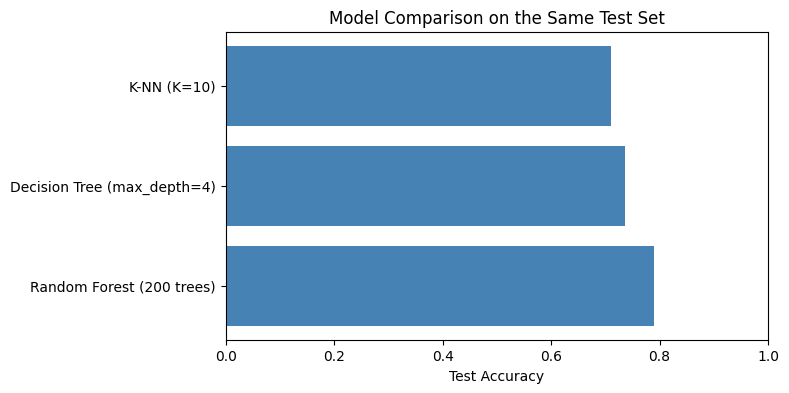

In [43]:
from sklearn.metrics import classification_report

models = {
    "Decision Tree (max_depth=4)": DecisionTreeClassifier(max_depth=4, random_state=42),
    "Random Forest (200 trees)": RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42),
    "K-NN (K=10)": KNeighborsClassifier(n_neighbors=10),
}

results = []
for name, m in models.items():
    if "K-NN" in name:
        m.fit(X_train_scaled, y_train)
        preds = m.predict(X_test_scaled)
    else:
        m.fit(X_train, y_train)
        preds = m.predict(X_test)
    acc = accuracy_score(y_test, preds)
    results.append((name, acc))

results_df = pd.DataFrame(results, columns=['Model', 'Test Accuracy']).sort_values('Test Accuracy', ascending=False)
print(results_df.to_string(index=False))

plt.figure(figsize=(7, 4))
plt.barh(results_df['Model'], results_df['Test Accuracy'], color='steelblue')
plt.xlabel("Test Accuracy")
plt.title("Model Comparison on the Same Test Set")
plt.xlim(0, 1)
plt.show()


## Summary Table: When Would You Use Each Algorithm?

| Algorithm | How it works | Pros | Cons |
|---|---|---|---|
| **Decision Tree** | Series of if-then questions, split by Gini/Entropy | Easy to visualize & explain; fast | Prone to overfitting if too deep |
| **Random Forest** | Many decision trees vote/average together | Usually more accurate & stable than one tree; less overfitting | Harder to visualize/explain (a "black box" of many trees); slower |
| **K-NN** | Looks at the K closest training points and votes | Very simple, no real "training"; naturally handles complex boundaries | Slow at prediction time on big datasets; sensitive to feature scaling; struggles in very high dimensions (the "curse of dimensionality") |

### A note on "the curse of dimensionality" for K-NN
As you add more and more features, the idea of "closest neighbor" starts to break down — in very high-dimensional space, most points end up roughly equally far from each other, making distance less meaningful. This is one reason K-NN is more commonly used with a small-to-moderate number of features.


# Summary of Today's Lecture

### Decision Trees
- Make predictions with a series of yes/no questions, forming a flowchart
- Use **Gini Impurity** (or Entropy) to measure how "mixed" a group is; choose splits with the highest **Information Gain**
- Fully grown trees easily **overfit**; control this with `max_depth`, `min_samples_split`, `min_samples_leaf`
- Big advantage: trees are **interpretable** — you can literally read the if-then logic

### Random Forests
- Combine MANY decision trees (an "ensemble"), each trained on a random bootstrap sample of data (**Bagging**) and a random subset of features at each split
- Final prediction: **majority vote** (classification) or **average** (regression) across all trees
- Reduces overfitting compared to a single deep tree — the "wisdom of crowds" effect
- Also gives us useful **feature importance** scores

### K-Nearest Neighbors (K-NN)
- A "lazy learner" — no real training, just stores the data and computes distances at prediction time
- Classifies a new point by majority vote among its **K nearest neighbors**, measured with **Euclidean distance**
- Small K → overfitting (jagged boundary); Large K → underfitting (over-smoothed)
- **Feature scaling is essential** since K-NN relies entirely on distance calculations

---
### Practice Exercises (try before next class)
1. Change `max_depth` on the Decision Tree to 1, 3, 6, and 10. Plot train vs. test accuracy for each — where does the model start to overfit?
2. Change `n_estimators` (number of trees) in the Random Forest to 5, 50, and 500. Does test accuracy keep improving, or does it plateau?
3. Try K-NN **without** scaling the features (use `X_train`/`X_test` directly instead of the scaled versions). Does accuracy get worse? Why?
4. Add a third feature to the dataset (e.g., `practice_tests_taken`) and retrain all three models. Which one improves the most?

# Bonus

## How to Calculate Training Accuracy in K-NN

To find **Training Accuracy**, we feed our training players back into the model as if they were new test players. Then we check how many the model gets right.

Let's calculate the prediction for **Player B $(2, 4)$** (whose actual ground truth $y$ is **Lose**) using $K = 3$.

### Step 1: Calculate distances from Player B $(2, 4)$ to all training players
*Yes, this includes calculating the distance from Player B to itself!*

| Training Player | Distance Calculation | Distance | Ground Truth ($y$) |
| :---: | :---: | :---: | :---: |
| **Player A** $(1, 2)$ | $\sqrt{(2-1)^2 + (4-2)^2} = \sqrt{1+4}$ | **$2.24$** | **Lose** |
| **Player B** $(2, 4)$ | $\sqrt{(2-2)^2 + (4-4)^2} = \sqrt{0+0}$ | **$0.00$** *(Itself!)* | **Lose** |
| **Player C** $(8, 3)$ | $\sqrt{(2-8)^2 + (4-3)^2} = \sqrt{36+1}$ | **$6.08$** | **Win** |
| **Player D** $(9, 1)$ | $\sqrt{(2-9)^2 + (4-1)^2} = \sqrt{49+9}$ | **$7.62$** | **Win** |

### Step 2: Let the 3 closest neighbors vote
The 3 closest players to Player B are **Player B itself** (0.00), **Player A** (2.24), and **Player C** (6.08).
*   **Lose ($y$):** 2 votes (B, A)
*   **Win ($y$):** 1 vote (C)

**Prediction:** **Lose**  
**Actual Ground Truth:** **Lose**  
**Result:** **Correct!**

If we repeated this for all 4 players (A, B, C, and D) and the model got all 4 correct, our **Training Accuracy would be 100%** ($\frac{4}{4}$).

---

## The "$K=1$" Trap (Great Exam Question!)

Ask your students: *"What happens to the training accuracy if we set $K = 1$?"*

If $K = 1$, the model only looks at the **single closest neighbor**. 
When we test any training player, the closest point to them in the dataset will always be **themselves** (distance = 0). 

*   Player A's closest neighbor is Player A $\rightarrow$ Predicts **Lose** (Correct)
*   Player B's closest neighbor is Player B $\rightarrow$ Predicts **Lose** (Correct)
*   Player C's closest neighbor is Player C $\rightarrow$ Predicts **Win** (Correct)
*   Player D's closest neighbor is Player D $\rightarrow$ Predicts **Win** (Correct)

> **The K=1 Rule:** If $K=1$, the training accuracy of a K-NN model is **always 100%**. 

But watch out! This doesn't mean the model is perfect. It just means it memorized the training data perfectly. If a new, unseen player joins, a $K=1$ model will often perform poorly because it overfits to noise.

## "Wait, why are we guessing labels we already know?"

We already know that Player B's ground truth is **Lose**. Why are we pretending we don't?

We do this to **evaluate our model**. Checking the training accuracy is like giving the model a "practice test" with open-book questions. If the model gets a wrong answer on data it has already seen, it tells us our model is struggling.

---

### What if the model gets a training label WRONG?

Let's look at what happens if we change the dial. What if we use **$K = 4$** instead of $K = 3$ to predict **Player B**?

The distances from Player B $(2, 4)$ to everyone else are:
1. **Player B** itself (Distance = $0.00$, Label = **Lose**)
2. **Player A** (Distance = $2.24$, Label = **Lose**)
3. **Player C** (Distance = $6.08$, Label = **Win**)
4. **Player D** (Distance = $7.62$, Label = **Win**)

Since $K = 4$, we let the **4 closest neighbors** vote:
*   **Lose ($y$):** 2 votes (B, A)
*   **Win ($y$):** 2 votes (C, D)

It's a tie! If our model breaks ties randomly (or defaults to Win), it might predict **Win**. 

*   **Model's Prediction:** **Win**
*   **Actual Ground Truth ($y$):** **Lose**
*   **Result:** **Incorrect!**

### What does a wrong training prediction actually mean?

If we get a different label than the ground truth, **we do NOT change the actual player's label.** Player B still lost their game—we can't rewrite history! 

Instead, a wrong prediction tells us two things:

1. **Our settings (hyperparameters) might be bad:** In this case, setting $K = 4$ was a bad choice because it included players (C and D) who are too far away and don't play like Player B. It tells us we should probably change $K$ back to $3$ or $1$.
2. **Our data has noise or overlap:** Sometimes, a "Win" player and a "Lose" player might have almost the exact same features (e.g., same practice hours, same ping). If their coordinates overlap, K-NN will make mistakes there.